# Jordan development data & AI explorer - Analysis notebook
this notebook analyzes trends and relationships in youth unemployment across Jordan and comparator countries (Lebanon - Saudi Arabia - Egypt), and the relationships with other development indicators (human development (HDI) - gender inequality (GII) - female labor forces).
all data used is from the postgreSQL database built for this project, combining World Bank World Development Indicators, the Jordan Department of Statistics, and the UNDP Human Development Report.

In [2]:
import pandas as pd
import psycopg2
import os
from dotenv import load_dotenv

load_dotenv()

conn = psycopg2.connect(dbname="jordan_dev_data", user="postgres", password=os.getenv("DB_PASSWORD"), host="localhost")

df = pd.read_sql("SELECT * FROM observations", conn)

print(df.shape)
print(df.head())


(506, 5)
   id  indicator_code     location_name  year   value
0   1  SL.UEM.1524.ZS  Egypt, Arab Rep.  2023  17.153
1   2  SL.UEM.1524.ZS  Egypt, Arab Rep.  2022  16.342
2   3  SL.UEM.1524.ZS  Egypt, Arab Rep.  2021  18.210
3   4  SL.UEM.1524.ZS  Egypt, Arab Rep.  2020  18.463
4   5  SL.UEM.1524.ZS  Egypt, Arab Rep.  2019  20.631


C:\Users\lenovo\AppData\Local\Temp\ipykernel_18572\605654214.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM observations", conn)


# Q1. what are the youth unemployment trends in jordan and across the 3 comparators, 2010-2023 ?

In [3]:
youth_unemp = df[df['indicator_code'] == 'SL.UEM.1524.ZS']

print(youth_unemp.shape)
youth_unemp.head()

(56, 5)


,id,indicator_code,location_name,year,value
0,1,SL.UEM.1524.ZS,"Egypt, Arab Rep.",2023,17.153
1,2,SL.UEM.1524.ZS,"Egypt, Arab Rep.",2022,16.342
2,3,SL.UEM.1524.ZS,"Egypt, Arab Rep.",2021,18.210
3,4,SL.UEM.1524.ZS,"Egypt, Arab Rep.",2020,18.463
4,5,SL.UEM.1524.ZS,"Egypt, Arab Rep.",2019,20.631


In [4]:
youth_unemp_wide = youth_unemp.pivot(index='year', columns='location_name', values='value')

youth_unemp_wide


location_name,"Egypt, Arab Rep.",Jordan,Lebanon,Saudi Arabia
year,,,,
2010,24.583,30.059,16.079,24.738
2011,29.426,30.787,17.134,25.110
2012,34.439,28.853,18.192,24.843
2013,34.120,29.536,19.112,26.946
2014,32.198,27.612,19.772,28.603
2015,34.160,30.914,20.591,28.156
2016,33.655,35.610,21.370,24.275
2017,32.644,35.438,22.039,31.504
2018,26.252,38.941,22.668,30.213


In [5]:
youth_unemp_change = youth_unemp_wide.diff()

youth_unemp_change

location_name,"Egypt, Arab Rep.",Jordan,Lebanon,Saudi Arabia
year,,,,
2010,NaN,NaN,NaN,NaN
2011,4.843,0.728,1.055,0.372
2012,5.013,-1.934,1.058,-0.267
2013,-0.319,0.683,0.920,2.103
2014,-1.922,-1.924,0.660,1.657
2015,1.962,3.302,0.819,-0.447
2016,-0.505,4.696,0.779,-3.881
2017,-1.011,-0.172,0.669,7.229
2018,-6.392,3.503,0.629,-1.291


In [6]:
%pip install psycopg2

Note: you may need to restart the kernel to use updated packages.


In [7]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


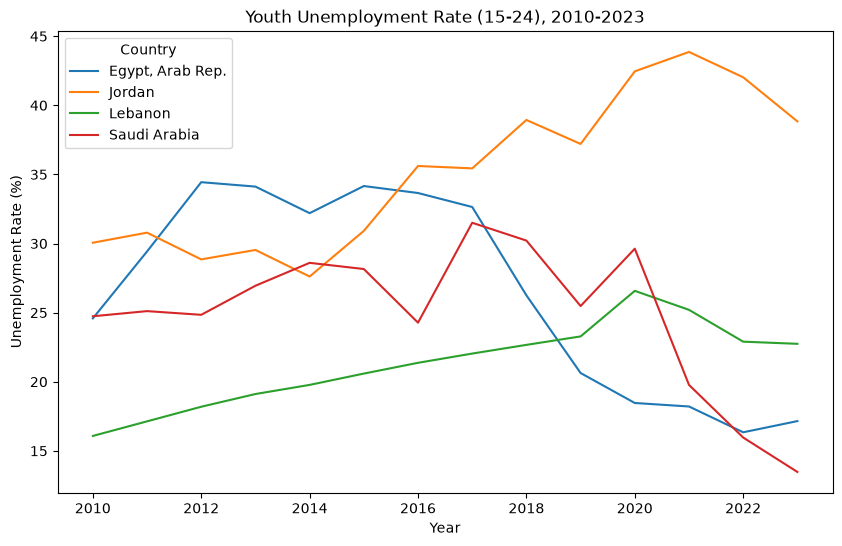

In [8]:
import matplotlib.pyplot as plt

youth_unemp_wide.plot(title='Youth Unemployment Rate (15-24), 2010-2023', figsize=(10, 6))
plt.xlabel('Year')
plt.ylabel('Unemployment Rate (%)')
plt.legend(title='Country')
plt.show()

# Interpretation
as we can see in the figure, Jordan trends upward overall and stays elevated through 2021-2023, unlike the others. in 2020 there is a spike across most countries. it could be because of the covid19 pandemic and lock down, but not necessarily, since Egypt actually moved opposite direction in 2020. Another interesting pattern, after 2020 Jordan stayed up high but Saudi Arabia dropped down sharply,and Lebanon too, just not as sharp as the Saudi drop.

# Q2. how does HDI correlate to youth unemployment? and female labor forces to GII?

In [9]:
hdi_subset = df[df['indicator_code'] == 'HDI']

merged_unemp_hdi = youth_unemp.merge(hdi_subset, on=["location_name", "year"], how='inner', suffixes=('_unemp', '_hdi'))

merged_unemp_hdi.head()

,id_unemp,indicator_code_unemp,location_name,year,value_unemp,id_hdi,indicator_code_hdi,value_hdi
0,1,SL.UEM.1524.ZS,"Egypt, Arab Rep.",2023,17.153,986,HDI,0.754
1,2,SL.UEM.1524.ZS,"Egypt, Arab Rep.",2022,16.342,982,HDI,0.751
2,3,SL.UEM.1524.ZS,"Egypt, Arab Rep.",2021,18.210,978,HDI,0.738
3,4,SL.UEM.1524.ZS,"Egypt, Arab Rep.",2020,18.463,974,HDI,0.736
4,5,SL.UEM.1524.ZS,"Egypt, Arab Rep.",2019,20.631,970,HDI,0.736


In [10]:
merged_unemp_hdi["value_unemp"].corr(merged_unemp_hdi["value_hdi"])

np.float64(-0.29446889754644306)

In [11]:
per_country_corr_unemp_hdi = merged_unemp_hdi.groupby('location_name').apply(lambda x: x['value_unemp'].corr(x['value_hdi']))

per_country_corr_unemp_hdi

location_name
Egypt, Arab Rep.   -0.732212
Jordan              0.419962
Lebanon            -0.192687
Saudi Arabia       -0.369055
dtype: float64

In [12]:
gii_subset = df[df['indicator_code'] == 'GII']
flfp_subset = df[df['indicator_code'] == 'SL.TLF.CACT.FE.ZS']
merged_gii_flfp = gii_subset.merge(flfp_subset, on=["location_name", "year"], how='inner', suffixes=('_gii', '_flfp'))

merged_gii_flfp.head()

,id_gii,indicator_code_gii,location_name,year,value_gii,id_flfp,indicator_code_flfp,value_flfp
0,1030,GII,"Egypt, Arab Rep.",2010,0.552,182,SL.TLF.CACT.FE.ZS,23.190
1,1031,GII,Jordan,2010,0.489,196,SL.TLF.CACT.FE.ZS,14.464
2,1032,GII,Lebanon,2010,0.433,210,SL.TLF.CACT.FE.ZS,22.817
3,1033,GII,Saudi Arabia,2010,0.754,224,SL.TLF.CACT.FE.ZS,17.628
4,1034,GII,"Egypt, Arab Rep.",2011,0.545,181,SL.TLF.CACT.FE.ZS,22.537


In [13]:
per_country_corr_gii_flfp = merged_gii_flfp.groupby('location_name').apply(lambda x: x['value_gii'].corr(x['value_flfp']))

per_country_corr_gii_flfp

location_name
Egypt, Arab Rep.    0.734463
Jordan             -0.617504
Lebanon             0.026300
Saudi Arabia       -0.616559
dtype: float64

In [14]:
gii_wide = gii_subset.pivot(index='year', columns='location_name', values='value')
flfp_wide = flfp_subset.pivot(index='year', columns='location_name', values='value')

gii_wide
flfp_wide

location_name,"Egypt, Arab Rep.",Jordan,Lebanon,Saudi Arabia
year,,,,
2010,23.190,14.464,22.817,17.628
2011,22.537,14.424,23.448,18.954
2012,22.511,13.864,24.089,19.758
2013,23.012,12.946,24.740,19.817
2014,23.166,12.283,25.401,20.278
2015,22.813,13.599,26.114,21.635
2016,23.072,15.051,26.885,22.866
2017,22.184,16.612,27.670,19.857
2018,18.415,14.649,28.470,21.824


# Interpretation
First, i computed the correlation for youth unemployment and HDI, and the result was -0.29 which is a weak to mid corr that matches the general idea of the lower youth unemployment, the higher HDI. However, this is not accurate since it mixes cross-country differences and within-country trends over time. Then i computed per country correlation. The results showed negative numbers for Egypt, Saudi, and Lebanon, which means the two indicators move in opposite directions, but surprisingly a positive one for Jordan, which means they're moving in the same direction. Does this mean the two indicators are not causing each other and its no more than coinsidence for the other countries?
Then, same per country correlation was computed for GII and female labor forces, and the results showed negative numbers for Jordan and Saudi, and positive numbers for Egypt and Lebanon, but we can't tell which indicator is falling and which is raising for each country, so we pivoted each indicator separately, and the results made it all clear. GII is falling for all four countries. female labor forces is kinda fluctuating but for Jordan and Saudi it's more on the raising side, for Lebanon its more stable, for Egypt it's more on falling side. 
In conclusion, correlation shows co-movement only, not causation or which variable is driving the other.

# Q3. Is there any anomalies/data gaps?

In [15]:
df.groupby(["indicator_code", "location_name"]).size()

indicator_code        location_name   
DOS_POVERTY_RATE_GOV  Ajloun               5
                      Amman                5
                      Aqaba                5
                      Balqa                5
                      Irbid                5
                      Jerash               5
                      Jordan               5
                      Kerak                5
                      Maan                 5
                      Madaba               5
                      Mafraq               5
                      Tafileh              5
                      Zarqa                5
GII                   Egypt, Arab Rep.    34
                      Jordan              24
                      Lebanon             17
                      Saudi Arabia        21
HDI                   Egypt, Arab Rep.    34
                      Jordan              34
                      Lebanon             19
                      Saudi Arabia        34
IT.NET.USER.ZS  

In [34]:
df_sorted = df.sort_values(["indicator_code", "location_name", "year"])
df_sorted["change"] = df_sorted.groupby(["indicator_code", "location_name"])["value"].pct_change()
df_sorted["raw_change"] = df_sorted.groupby(["indicator_code", "location_name"])["value"].diff()

df_sorted

,id,indicator_code,location_name,year,value,change,raw_change
259,260,DOS_POVERTY_RATE_GOV,Ajloun,1997,17.300,NaN,NaN
260,261,DOS_POVERTY_RATE_GOV,Ajloun,2002,9.700,-0.439306,-7.600
261,262,DOS_POVERTY_RATE_GOV,Ajloun,2006,17.700,0.824742,8.000
262,263,DOS_POVERTY_RATE_GOV,Ajloun,2008,13.300,-0.248588,-4.400
263,264,DOS_POVERTY_RATE_GOV,Ajloun,2010,25.600,0.924812,12.300
...,...,...,...,...,...,...,...
46,47,SL.UEM.1524.ZS,Saudi Arabia,2019,25.477,-0.156754,-4.736
45,46,SL.UEM.1524.ZS,Saudi Arabia,2020,29.627,0.162892,4.150
44,45,SL.UEM.1524.ZS,Saudi Arabia,2021,19.772,-0.332636,-9.855
43,44,SL.UEM.1524.ZS,Saudi Arabia,2022,15.964,-0.192596,-3.808


In [35]:
df_sorted.reindex(df_sorted["change"].abs().sort_values(ascending=False).index).head(15)

,id,indicator_code,location_name,year,value,change,raw_change
128,129,NY.GDP.MKTP.KD.ZG,Jordan,2021,3.752013,-4.255330,4.904588
157,158,NY.GDP.MKTP.KD.ZG,Saudi Arabia,2020,-3.804789,-3.303714,-5.456378
145,146,NY.GDP.MKTP.KD.ZG,Lebanon,2018,-1.884706,-3.087095,-2.787734
156,157,NY.GDP.MKTP.KD.ZG,Saudi Arabia,2021,6.519597,-2.713524,10.324386
144,145,NY.GDP.MKTP.KD.ZG,Lebanon,2019,-6.914925,2.668968,-5.030219
147,148,NY.GDP.MKTP.KD.ZG,Lebanon,2016,1.554549,2.362491,1.092229
143,144,NY.GDP.MKTP.KD.ZG,Lebanon,2020,-21.399900,2.094741,-14.484975
151,152,NY.GDP.MKTP.KD.ZG,Lebanon,2012,2.564791,1.957078,1.697451
159,160,NY.GDP.MKTP.KD.ZG,Saudi Arabia,2018,3.226951,1.729830,2.044844
129,130,NY.GDP.MKTP.KD.ZG,Jordan,2020,-1.152575,-1.620889,-3.008905


In [38]:
df_sorted.loc[df_sorted.groupby("indicator_code")["raw_change"].apply(lambda x: x.abs().idxmax())]

,id,indicator_code,location_name,year,value,change,raw_change
270,271,DOS_POVERTY_RATE_GOV,Tafileh,2002,10.6000,-0.563786,-13.700000
465,1045,GII,Saudi Arabia,2013,0.3090,-0.587450,-0.440000
404,984,HDI,Lebanon,2022,0.7550,0.030014,0.022000
104,105,IT.NET.USER.ZS,Saudi Arabia,2017,94.1756,0.257699,19.296325
143,144,NY.GDP.MKTP.KD.ZG,Lebanon,2020,-21.3999,2.094741,-14.484975
213,214,SL.TLF.CACT.FE.ZS,Saudi Arabia,2020,29.3080,0.202873,4.943000
44,45,SL.UEM.1524.ZS,Saudi Arabia,2021,19.7720,-0.332636,-9.855000


In [45]:
df_sorted.groupby(["indicator_code", "location_name"])[["raw_change"]].describe()

raw_change                       \
                                           count      mean        std   
indicator_code       location_name                                      
DOS_POVERTY_RATE_GOV Ajloun                  4.0  2.075000   9.577534   
                     Amman                   4.0 -2.050000   5.836951   
                     Aqaba                   4.0  0.550000   4.850086   
                     Balqa                   4.0 -0.225000   3.779219   
                     Irbid                   4.0 -2.750000   6.540387   
                     Jerash                  4.0  0.275000   2.322893   
                     Jordan                  4.0 -1.725000   3.707987   
                     Kerak                   4.0  0.100000   6.473021   
                     Maan                    4.0 -2.675000  11.741486   
                     Madaba                  4.0 -2.200000   7.733477   
                     Mafraq                  4.0 -4.175000   9.777312   
                     Tafileh                 4.0 -1.775000   9.425984   
                     Zarqa                   4.0 -0.550000   6.100546   
GII                  Egypt, Arab Rep.       33.0 -0.007697   0.024898   
                     Jordan                 23.0 -0.007870   0.012524   
                     Lebanon                16.0 -0.003312   0.012919   
                     Saudi Arabia           20.0 -0.027600   0.097682   
HDI                  Egypt, Arab Rep.       33.0  0.005515   0.002852   
                     Jordan                 33.0  0.004091   0.004680   
                     Lebanon                18.0  0.002333   0.009810   
                     Saudi Arabia           33.0  0.006970   0.003670   
IT.NET.USER.ZS       Egypt, Arab Rep.       13.0  4.031685   4.123119   
                     Jordan                 13.0  5.025726   2.756573   
                     Lebanon                13.0  2.925069   3.594073   
                     Saudi Arabia           13.0  4.538462   5.135967   
NY.GDP.MKTP.KD.ZG    Egypt, Arab Rep.       13.0 -0.106689   1.791270   
                     Jordan                 13.0  0.037791   1.742279   
                     Lebanon                13.0 -0.671978   6.755039   
                     Saudi Arabia           13.0 -0.345917   5.790712   
SL.TLF.CACT.FE.ZS    Egypt, Arab Rep.       13.0 -0.362462   1.680648   
                     Jordan                 13.0  0.113000   1.265673   
                     Lebanon                13.0 -0.044846   1.368734   
                     Saudi Arabia           13.0  1.280769   2.094053   
SL.UEM.1524.ZS       Egypt, Arab Rep.       13.0 -0.571538   3.349445   
                     Jordan                 13.0  0.675231   2.797210   
                     Lebanon                13.0  0.512692   1.312426   
                     Saudi Arabia           13.0 -0.866462   4.323187   

                                                                       \
                                             min        25%       50%   
indicator_code       location_name                                      
DOS_POVERTY_RATE_GOV Ajloun            -7.600000  -5.200000  1.800000   
                     Amman            -10.400000  -3.425000 -0.450000   
                     Aqaba             -3.700000  -2.275000 -0.750000   
                     Balqa             -4.000000  -2.875000 -0.650000   
                     Irbid            -12.200000  -4.325000 -0.700000   
                     Jerash            -1.700000  -1.025000 -0.400000   
                     Jordan            -7.100000  -2.675000 -0.450000   
                     Kerak             -4.600000  -3.925000 -2.250000   
                     Maan             -13.200000 -11.850000 -4.500000   
                     Madaba           -13.200000  -3.825000 -0.250000   
                     Mafraq           -12.700000 -11.050000 -6.450000   
                     Tafileh          -13.700000  -6.350000 -0.950000   
                     Z

In [47]:
df_sorted["z_score"] = df_sorted.groupby(["indicator_code", "location_name"])["raw_change"].transform(lambda x: (x - x.mean()) / x.std())

df_sorted[df_sorted["z_score"].abs() > 2].sort_values("z_score", key=abs, ascending=False)

,id,indicator_code,location_name,year,value,change,raw_change,z_score
474,1054,GII,"Egypt, Arab Rep.",2016,0.412000,-0.239852,-0.130000,-4.912183
465,1045,GII,Saudi Arabia,2013,0.309000,-0.587450,-0.440000,-4.221850
104,105,IT.NET.USER.ZS,Saudi Arabia,2017,94.175600,0.257699,19.296325,2.873434
128,129,NY.GDP.MKTP.KD.ZG,Jordan,2021,3.752013,-4.255330,4.904588,2.793352
397,977,HDI,Saudi Arabia,2020,0.875000,-0.003417,-0.003000,-2.716649
402,982,HDI,"Egypt, Arab Rep.",2022,0.751000,0.017615,0.013000,2.624635
484,1064,GII,Lebanon,2018,0.381000,-0.088517,-0.037000,-2.607630
59,60,IT.NET.USER.ZS,"Egypt, Arab Rep.",2020,71.914201,0.255423,14.631335,2.570784
427,1007,GII,Jordan,2003,0.554000,-0.065767,-0.039000,-2.485700
199,200,SL.TLF.CACT.FE.ZS,Lebanon,2020,25.944000,-0.114116,-3.342000,-2.408908


# Interpretation
Lebanon's HDI has only 19 of a possible 34 years (1990-2023), and GII has very different coverage per country (Egypt 34, Jordan 24, Saudi Arabia 21, Lebanon only 17) because the index was rolled out to different countries at different times. The 4 WDI indicators (internet users, GDP growth, female labor force participation, youth unemployment) all 14/14 for all four countries, checked and confirmed no missing years. DOS poverty rate having 5 rows per governorate is not that data is missing from an annual series, it's that Jordan's Department of Statistics doesn't run the household poverty survey every year.

There are two countries each showing one sharply oversized GII move in a single year, at completely different times, Egypt and Saudi. This is because UNDP periodically updates how GII is calculated, not an actual one-year social shift in gender inequality. Another observation is the drop in HDI for Jordan, Lebanon, and Saudi in the same year, 2020. Then in 2022, all the four countries show positive anomalies. This lines up with the global COVID19 pandemic. Lebanon's female labor force participation dropped sharply in 2020, Lebanon's unemployment spiked in 2020, Jordan's GDP growth rebounded hard in 2021, and Lebanon's GDP growth fluctuates wildly in both directions in consecutive years, (raw changes -14.5 in 2020, then +14.4 in 2021). Given Lebanon's currency/hyperinflation crisis during this period, this probably says more about how unreliable GDP measurement becomes during that kind of crisis than about a real economic issue of that exact size. 
To sum it up, COVID19's effects show up consistently across multiple different indicators and multiple countries.

# Overall Limitations
This analysis covers only 4 countries (Jordan, Egypt, Lebanon, and Saudi Arabia), which limits how far any of these findings can be generalized.

For the correlation analysis (Q2), the pooled correlation between HDI and youth unemployment mixes cross-country differences and within-country trends over time, which is why per-country correlations were computed instead. But correlation shows co-movement only, not causation or which variable is driving the other, this applies to every correlation result in this notebook, not just the ones that matched expectations going in.

For the anomaly analysis (Q3), some of the largest single-year swings (notably in GII for Egypt and Saudi Arabia) are likely explained by UNDP periodically updating how GII is calculated, not an actual one-year social shift in gender inequality, a reminder that a statistical outlier doesn't always reflect a real-world event, and needs checking against context before being reported as a finding.